# <h1> <strong> Colab Specific + mlflow </strong> </h1>

### 1.1. Importing google drive

1.1.1. Moving big files to colab's local disk

In [41]:
import shutil
import os

In [44]:
# Logs for mlflow
mlflow_logs = '/content/drive/MyDrive/mlruns'
local_mlflow_logs ='/content/mlruns'

# Logs for Tensorflow Tensorboard
tbrd_logs = "/content/drive/MyDrive/master_folder/semantic-segmentation/experiments/tbrd_logs/fit/"
local_tbrd_logs = "/content/tbr_logs/fit"

# checkpoints
checkpoints = "/content/drive/MyDrive/master_folder/semantic-segmentation/experiments/checkpoints"
local_checkpoints = "/content/local_checkpoints"

datasets1 = "/content/drive/MyDrive/master_folder/semantic-segmentation/experiments/train_data"
datasets2 = "/content/drive/MyDrive/master_folder/semantic-segmentation/experiments/valid_data"

local_datasets = "/content/local_datasets"

In [42]:
# Create the local directories if it they don't exist
os.makedirs(local_mlflow_logs, exist_ok=True)
os.makedirs(local_tbrd_logs, exist_ok=True)
os.makedirs(local_checkpoints, exist_ok=True)
os.makedirs(local_datasets, exist_ok=True)

In [45]:
# models
# Copy files from Google Drive to local disk
shutil.copytree(datasets1, local_datasets, dirs_exist_ok=True)
print(f"Copied mlflow directory from {datasets1} to {local_datasets}")

Copied mlflow directory from /content/drive/MyDrive/master_folder/semantic-segmentation/experiments/train_data to /content/local_datasets


In [64]:
shutil.copytree(datasets2, local_datasets, dirs_exist_ok=True)
print(f"Copied mlflow directory from {datasets2} to {local_datasets}")

Copied mlflow directory from /content/drive/MyDrive/master_folder/semantic-segmentation/experiments/valid_data to /content/local_datasets


In [ ]:
# models
# Copy files from Google Drive to local disk
shutil.copytree(datasets1, local_datasets, dirs_exist_ok=True)
print(f"Copied mlflow directory from {datasets2} to {local_datasets}")

### 1. colab specific imports

In [95]:
# most frequent snippets
from __future__ import absolute_import, division, print_function, unicode_literals
import sys

# authentificate to save files on google drive
def import_drive():
    from google.colab import drive
    drive.mount('/content/drive')

def change_dir(path):
    import os
    os.chdir(path)

In [96]:
import_drive()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
path = "/content/drive/MyDrive/master_folder/semantic-segmentation/experiments/"
change_dir(path)

### 1.2. set mlflow locally or on cloud

In [8]:
# !pip install mlflow
# !pip install pyngrok
import mlflow
from pyngrok import ngrok
import os

In [9]:
# !pip install keras-cv-attention-models
tracking_uri = '/content/drive/MyDrive/mlruns'
os.makedirs(tracking_uri, exist_ok=True)
mlflow.set_tracking_uri(tracking_uri)
experiment_name = "v2_09/06/24 - SegFormer"
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='/content/drive/MyDrive/mlruns/994866691474661340', creation_time=1717854678257, experiment_id='994866691474661340', last_update_time=1717854678257, lifecycle_stage='active', name='v2_09/06/24 - SegFormer', tags={}>

In [ ]:
# import shutil
# import os

# # Define the source and destination directories
# local_tracking_dir = '/content/mlruns'
# drive_tracking_dir = '/content/drive/MyDrive/mlruns_backup'

# # Ensure the destination directory exists
# os.makedirs(drive_tracking_dir, exist_ok=True)

# # Copy the local tracking directory to Google Drive
# shutil.copytree(local_tracking_dir, drive_tracking_dir, dirs_exist_ok=True)

# print(f"Copied MLflow tracking directory from {local_tracking_dir} to {drive_tracking_dir}")


Copied MLflow tracking directory from /content/mlruns to /content/drive/MyDrive/mlruns_backup


In [98]:
experiment_name = "v2_09/06/24 - SegFormer"
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='/content/drive/MyDrive/mlruns/994866691474661340', creation_time=1717854678257, experiment_id='994866691474661340', last_update_time=1717854678257, lifecycle_stage='active', name='v2_09/06/24 - SegFormer', tags={}>

In [99]:
# Authenticate ngrok with your authtoken
# Replace 'your-authtoken' with the actual token you copied from the ngrok dashboard
ngrok.set_auth_token('2gluH2W7INNUrnODbUAMZ9UnOMe_541YvYEvmSe56bcgqv1AH')

In [100]:
# Step 5: Start the MLflow UI
get_ipython().system_raw("mlflow ui --backend-store-uri /content/drive/MyDrive/mlruns &")

In [101]:
public_url = ngrok.connect(addr='5000')

In [102]:
print(f"MLflow UI is available at: {public_url}")

MLflow UI is available at: NgrokTunnel: "https://400f-34-126-116-92.ngrok-free.app" -> "http://localhost:5000"


In [ ]:
# mlflow.end_run()

##### **Azure specific**

In [ ]:
# to be run on a server: mlflow server --backend-store-uri sqlite:////data/mlflow/backend/mlflow.db --default-artifact-root /data/mlflow/artifacts

In [ ]:
# !apt-get install openssh-client -y

# ssh_host = '172.212.92.90'
# ssh_user = 'azureuser'
# ssh_key_path = 'test-mlflow_key.pem'

In [ ]:
# artifact_location = f'sftp://{ssh_user}@{ssh_host}/path/to/artifact/directory'
# mlflow.set_experiment('experiment_name', artifact_location=artifact_location)

In [ ]:
# mlflow server --backend-store-uri /path/to/mlflow/backend --default-artifact-root /path/to/mlflow/artifacts --host 0.0.0.0 --port 5000

###### connect to remote azure server.

In [ ]:
# mlflow.set_tracking_uri(f"http://{azure_vm_ip}:{mlflow_port}")

In [ ]:
# !pip install numba

# from numba import cuda
# device = cuda.get_current_device()
# device.reset()

### 1.3. Setting up Github

In [ ]:
# Remove existing SSH keys
!rm -f ~/.ssh/id_rsa ~/.ssh/id_rsa.pub ~/.ssh/known_hosts ~/.ssh/config

In [ ]:
# Generate a new SSH key pair
# !ssh-keygen -t rsa -b 4096 -C "cool.lstm@gmail.com" -f ~/.ssh/id_rsa -N ""

In [ ]:
from google.colab import userdata

In [ ]:
# cat ~/.ssh/id_rsa

In [ ]:
# import os
private_key = userdata.get('SSH_GITHUB_PRIVATE_KEY')
public_key = userdata.get('SSH_GITHUB_PUBLIC_KEY')

In [ ]:
# private_key

In [ ]:
# Create the .ssh directory if it doesn't exist
!mkdir -p ~/.ssh

In [ ]:
# Save the private key
with open('/root/.ssh/id_rsa', 'w') as f:
    f.write(private_key)

In [ ]:
# Save the public key
with open('/root/.ssh/id_rsa.pub', 'w') as f:
    f.write(public_key)

In [ ]:
# Set the correct permissions
!chmod 700 ~/.ssh
!chmod 600 ~/.ssh/id_rsa
!chmod 644 ~/.ssh/id_rsa.pub

In [ ]:
# Add GitHub to the list of known hosts to prevent manual confirmation
!ssh-keyscan -t rsa github.com >> ~/.ssh/known_hosts

# github.com:22 SSH-2.0-babeld-32c28593


In [ ]:
# Configure the SSH config file for GitHub
config = """
Host github.com
  HostName github.com
  User git
  IdentityFile ~/.ssh/id_rsa
  StrictHostKeyChecking no
"""

with open('/root/.ssh/config', 'w') as f:
    f.write(config)

In [ ]:
# Set the correct permissions for the config file
!chmod 600 ~/.ssh/config

In [ ]:
!ssh -T git@github.com

Load key "/root/.ssh/id_rsa": error in libcrypto
git@github.com: Permission denied (publickey).


In [ ]:
!ssh -T git@github.com

Load key "/root/.ssh/id_rsa": error in libcrypto
git@github.com: Permission denied (publickey).


In [ ]:
# !ssh -vvv -T git@github.com

## Libraries

In [103]:
import os, json, pickle
import numpy as np
import cv2
import json
import gc
from PIL import Image
import requests
import tqdm
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from datetime import datetime

from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.metrics import AUC
from tensorflow.keras.callbacks import Callback

import tensorflow as tf
import datetime
import tensorflow as tf
from transformers import TFSegformerForSemanticSegmentation, SegformerImageProcessor
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.metrics import IoU, SparseCategoricalAccuracy

# import mlflow
# import mlflow.tensorflow
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import Mean, SparseCategoricalAccuracy

from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation, TFSegformerForSemanticSegmentation
from transformers import SegformerConfig

## Data and Model Preparation

## Display an Example from the dataset

Image path: cityscapes_leftImg8bit_trainvaltest/leftImg8bit/train/zurich/zurich_000121_000019_leftImg8bit.png
Label path: cityscapes_gtFine_trainvaltest/gtFine/train/zurich/zurich_000121_000019_gtFine_labelIds.png


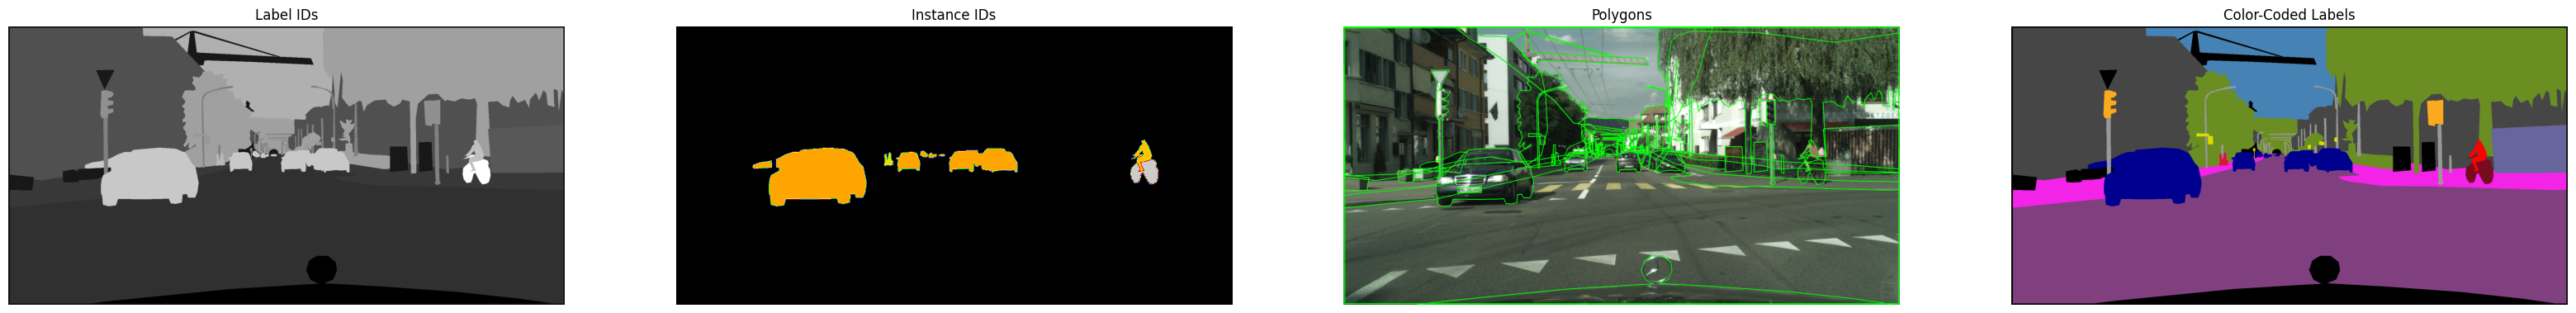

In [ ]:
def load_image(image_path):
    if not os.path.exists(image_path):
        print(f"Image path does not exist: {image_path}")
        return None
    image = cv2.imread(image_path)
    if image is None:
        print(f"Failed to load image: {image_path}")
        return None
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

def load_label(label_path):
    if not os.path.exists(label_path):
        print(f"Label path does not exist: {label_path}")
        return None
    label = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
    if label is None:
        print(f"Failed to load label: {label_path}")
        return None
    return label

def load_instance_id(label_path):
    label = cv2.imread(label_path, cv2.IMREAD_UNCHANGED)
    return label

def load_json(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    return data

def load_color_label(color_label_path):
    color_label = cv2.imread(color_label_path)
    color_label = cv2.cvtColor(color_label, cv2.COLOR_BGR2RGB)
    return color_label

def visualize_all_labels(image_path, label_path, instance_path, json_path, color_label_path):
    image = load_image(image_path)
    label = load_label(label_path)
    instance = load_instance_id(instance_path)
    polygons = load_json(json_path)
    color_label = load_color_label(color_label_path)

    plt.figure(figsize=(40, 25))

    plt.subplot(1, 4, 1)
    plt.title("Label IDs")
    plt.imshow(label, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.title("Instance IDs")
    plt.imshow(instance, cmap='nipy_spectral')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.title("Polygons")
    plt.imshow(image)
    for obj in polygons['objects']:
        polygon = obj['polygon']
        polygon = np.array(polygon).reshape((-1, 1, 2)).astype(np.int32)
        cv2.polylines(image, [polygon], True, (0, 255, 0), 2)
    plt.imshow(image)
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.title("Color-Coded Labels")
    plt.imshow(color_label)
    plt.axis('off')

    plt.show()

# Example file
city = 'zurich'
image_num = '000121'
frame_num = '000019'
# Directory paths (update these with actual paths)

leftImg8bit_dir = 'cityscapes_leftImg8bit_trainvaltest/leftImg8bit/train/'
gtFine_dir = 'cityscapes_gtFine_trainvaltest/gtFine/train/'


# Example paths (update these with actual paths)
image_filename = f'{city}_{image_num}_{frame_num}_leftImg8bit.png'
label_filename = f'{city}_{image_num}_{frame_num}_gtFine_labelIds.png'
instance_filename = f'{city}_{image_num}_{frame_num}_gtFine_instanceIds.png'
json_filename = f'{city}_{image_num}_{frame_num}_gtFine_polygons.json'
color_label_filename = f'{city}_{image_num}_{frame_num}_gtFine_color.png'

image_path = os.path.join(leftImg8bit_dir, city, image_filename)
label_path = os.path.join(gtFine_dir, city, label_filename)
instance_path = os.path.join(gtFine_dir, city, instance_filename)
json_path = os.path.join(gtFine_dir, city, json_filename)
color_label_path = os.path.join(gtFine_dir, city, color_label_filename)


# Print paths to verify
print(f"Image path: {image_path}")
print(f"Label path: {label_path}")


visualize_all_labels(image_path, label_path, instance_path, json_path, color_label_path)


## 2. Data pipeline preparation for DL Segmentation Models

## 2.1. Prepare paths to training and validation sets

In [ ]:
# Function to load an image and convert it to a NumPy array
def load_image(filepath):
    return np.array(Image.open(filepath))


def get_cityscapes_file_paths(img_root_dir, label_root_dir, subset):
    img_paths = []
    label_paths = []
    color_labels = []
    subset_dir = os.path.join(img_root_dir, subset)

    for city in os.listdir(subset_dir):
        city_img_dir = os.path.join(subset_dir, city)
        city_label_dir = os.path.join(label_root_dir, subset, city)
        city_color_label_dir = os.path.join(label_root_dir, subset, city)
        for img_file in os.listdir(city_img_dir):
            if img_file.endswith('_leftImg8bit.png'):
                img_path = os.path.join(city_img_dir, img_file)

                label_file = img_file.replace('_leftImg8bit.png', '_gtFine_labelIds.png')
                label_path = os.path.join(city_label_dir, label_file)

                color_file = img_file.replace('_leftImg8bit.png', '_gtFine_color.png')
                color_path = os.path.join(city_color_label_dir, color_file)


                if os.path.exists(label_path):
                    img_paths.append(img_path)
                    label_paths.append(label_path)
                    color_labels.append(color_path)
                else:
                    print(f"Warning: Label file {label_path} does not exist.")

    return img_paths, label_paths, color_labels

# Example usage:
img_root_dir = 'cityscapes_leftImg8bit_trainvaltest/leftImg8bit/'
label_root_dir = 'cityscapes_gtFine_trainvaltest/gtFine'

train_img_paths, train_label_paths, train_color_labels = get_cityscapes_file_paths(img_root_dir, label_root_dir, 'train')
val_img_paths, val_label_paths, val_color_labels = get_cityscapes_file_paths(img_root_dir, label_root_dir, 'val')

print(f"Number of training images: {len(train_img_paths)}")
print(f"Number of validation images: {len(val_img_paths)}")
print(f'Number of validation imabes: {len(val_color_labels)}')

Number of training images: 2975
Number of validation images: 500
Number of validation imabes: 500


In [1]:

# Original 30 classes
original_classes = [
    'road', 'sidewalk', 'parking', 'rail track', 'person', 'rider', 'car', 'truck', 'bus', 'on rails',
    'motorcycle', 'bicycle', 'caravan', 'trailer', 'building', 'wall', 'fence', 'guard rail', 'bridge',
    'tunnel', 'pole', 'pole group', 'traffic sign', 'traffic light', 'vegetation', 'terrain', 'sky',
    'ground', 'dynamic', 'static'
]

# Mapping to 8 major groups
class_mapping = {
    'road': 'flat', 'sidewalk': 'flat', 'parking': 'flat', 'rail track': 'flat',
    'person': 'human', 'rider': 'human',
    'car': 'vehicle', 'truck': 'vehicle', 'bus': 'vehicle', 'on rails': 'vehicle',
    'motorcycle': 'vehicle', 'bicycle': 'vehicle', 'caravan': 'vehicle', 'trailer': 'vehicle',
    'building': 'construction', 'wall': 'construction', 'fence': 'construction', 'guard rail': 'construction',
    'bridge': 'construction', 'tunnel': 'construction',
    'pole': 'object', 'pole group': 'object', 'traffic sign': 'object', 'traffic light': 'object',
    'vegetation': 'nature', 'terrain': 'nature',
    'sky': 'sky',
    'ground': 'void', 'dynamic': 'void', 'static': 'void'
}

# New labels for the 8 major groups
new_labels = {
    'flat': 0, 'human': 1, 'vehicle': 2, 'construction': 3, 'object': 4, 'nature': 5, 'sky': 6, 'void': 7
}

# Example usage
def load_image(filepath):
    return np.array(Image.open(filepath))

def map_labels_np(label_image, original_classes, class_mapping, new_labels):
    # Ensure the label_image is in integer format
    label_image = label_image.astype(np.int32)

    # Create a mapping array from original class indices to new class indices
    mapping_array = np.full(256, new_labels['void'], dtype=np.int32)  # Use a larger array to handle out-of-bounds

    for original_class, new_class in class_mapping.items():
        original_class_index = original_classes.index(original_class)
        new_class_index = new_labels[new_class]
        mapping_array[original_class_index] = new_class_index

    # Map the labels using the mapping array, setting out-of-bound values to 'void'
    mapped_label_image = np.where(label_image < len(mapping_array), mapping_array[label_image], new_labels['void'])

    return mapped_label_image


In [2]:
def plot_image(image, segmentation, image_title ='Original Image'):
    # Sample data: replace these with your actual image and segmentation mask
    # Plotting the image and its segmentation
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Original image
    axes[0].imshow(image)
    axes[0].set_title(image_title)
    axes[0].axis('off')

    # Segmentation mask
    axes[1].imshow(image)
    axes[1].imshow(segmentation, cmap='jet', alpha=0.5)  # Overlaying segmentation with some transparency
    axes[1].set_title('Segmentation Applied')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
train_np = np.array(train_img_paths)
val_label_np = np.array(train_label_paths)
val_color_np = np.array(train_color_labels)

In [ ]:
num = 102

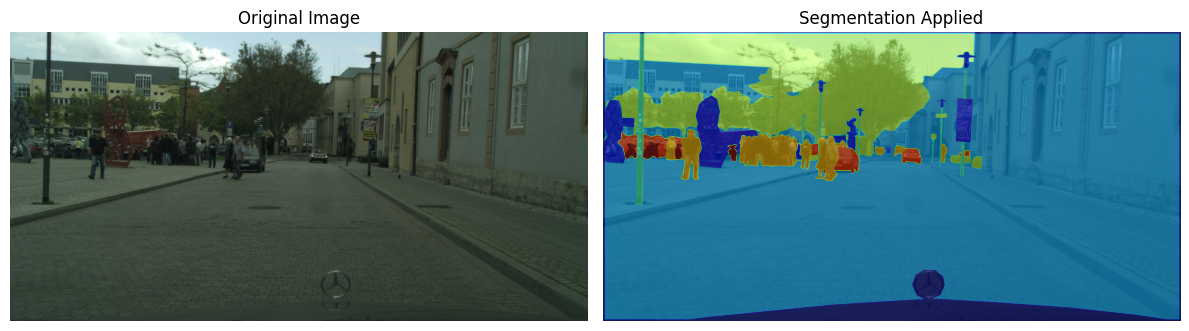

In [ ]:
for tr, val, col in zip(train_np, val_label_np, val_color_np):
    # Load the image and segmentation mask
    image = load_image(tr)
    segmentation = load_image(val)
    mapped_image = map_labels_np(segmentation, original_classes, class_mapping, new_labels)
    plot_image(image, mapped_image)
    break

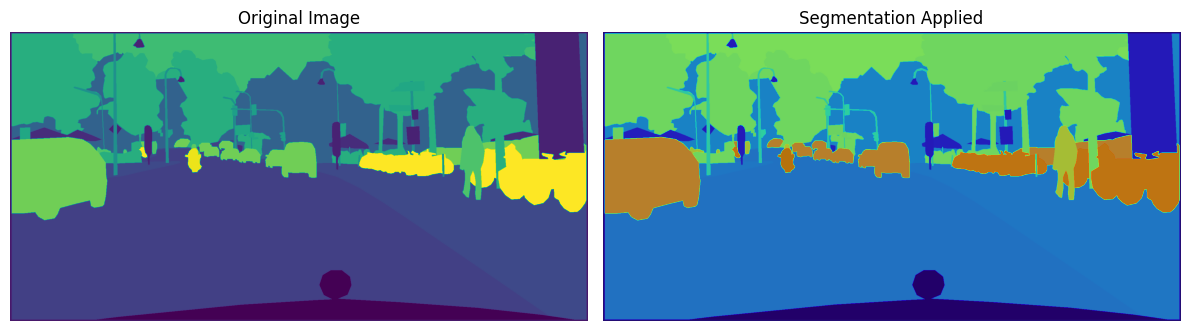

In [ ]:
for tr, val, col in zip(train_np[num:], val_label_np[num:], val_color_np[num:]):
    # Load the image and segmentation mask
    image = load_image(tr)
    segmentation = load_image(val)
    mapped_image = map_labels_np(segmentation, original_classes, class_mapping, new_labels)
    plot_image(segmentation, mapped_image)
    break

#### Trained images

In [ ]:
ls

 checkpoints/            cityscapes_gtFine_trainvaltest/           unet-pet-tensorflow.zip
 checkpoints2/           cityscapes_gtFine_trainvaltest.zip        Untitled0.ipynb
'Copy of segmentation_experiments.ipynb'   cityscapes_leftImg8bit_trainvaltest/      Untitled1.ipynb
 data_import.ipynb       cityscapes_leftImg8bit_trainvaltest.zip   weights.25-0.87.hdf5
 dims1024/               segmentation_experiments.ipynb                                 weights.27-0.85.hdf5
 dims2048/               segformer_weights.pth                        X_train_lab_segformer.pickle
 efficientvit/           static/                                      X_train_segformer.pickle
 img1.jpg                test/                                        X_val_labels_segformer.pickle
 mlruns/                 training_history.json                        X_val_segformer.pickle
 other_checkpoints/      unet-pet-tensorflow/


In [ ]:
num=102
# Load the model
model_path = 'checkpoints/final_model.keras'
model = keras.models.load_model(model_path)

1/1 [==============================] - 15s 15s/step


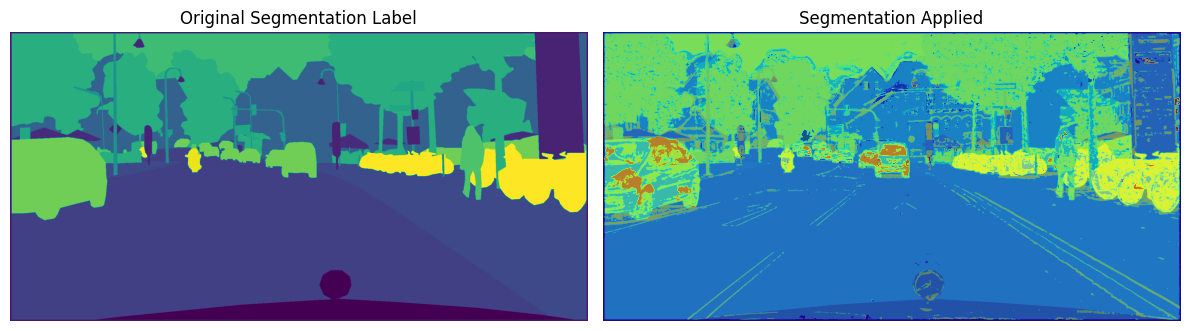

In [ ]:
for tr, val, col in zip(train_np[num:], val_label_np[num:], val_color_np[num:]):
    # Load the image and segmentation mask
    # print(type(tr))
    image = np.expand_dims(load_image(tr), axis=0)
    # print(type(image))
    # print(image.shape)
    segmentation = load_image(val)
    mapped_image = map_labels_np(segmentation, original_classes, class_mapping, new_labels)
    predicted = model.predict(image)
    # Since the output might be one-hot encoded or logits, we need to convert it to a class map
    prediction_argmax = np.argmax(predicted, axis=-1)
    # import pdb; pdb.set_trace()
    prediction_squeezed = np.squeeze(prediction_argmax)
    # plot_image(image, prediction_squeezed)
    plot_image(segmentation, prediction_squeezed, image_title='Original Segmentation Label')
    break

#### For ChatGPT

In [ ]:
# Original 30 classes
original_classes = [
    'road', 'sidewalk', 'parking', 'rail track', 'person', 'rider', 'car', 'truck', 'bus', 'on rails',
    'motorcycle', 'bicycle', 'caravan', 'trailer', 'building', 'wall', 'fence', 'guard rail', 'bridge',
    'tunnel', 'pole', 'pole group', 'traffic sign', 'traffic light', 'vegetation', 'terrain', 'sky',
    'ground', 'dynamic', 'static'
]

# Mapping to 8 major groups
class_mapping = {
    'road': 'flat', 'sidewalk': 'flat', 'parking': 'flat', 'rail track': 'flat',
    'person': 'human', 'rider': 'human',
    'car': 'vehicle', 'truck': 'vehicle', 'bus': 'vehicle', 'on rails': 'vehicle',
    'motorcycle': 'vehicle', 'bicycle': 'vehicle', 'caravan': 'vehicle', 'trailer': 'vehicle',
    'building': 'construction', 'wall': 'construction', 'fence': 'construction', 'guard rail': 'construction',
    'bridge': 'construction', 'tunnel': 'construction',
    'pole': 'object', 'pole group': 'object', 'traffic sign': 'object', 'traffic light': 'object',
    'vegetation': 'nature', 'terrain': 'nature',
    'sky': 'sky',
    'ground': 'void', 'dynamic': 'void', 'static': 'void'
}

# New labels for the 8 major groups
new_labels = {
    'flat': 0, 'human': 1, 'vehicle': 2, 'construction': 3, 'object': 4, 'nature': 5, 'sky': 6, 'void': 7
}

def map_labels_tf(label_image, original_classes, class_mapping, new_labels):
    label_image = tf.squeeze(label_image, axis=-1)  # Remove the last dimension
    mapped_label_image = tf.zeros_like(label_image, dtype=tf.int32)  # Ensure dtype is int32
    for original_class, new_class in class_mapping.items():
        original_class_index = original_classes.index(original_class)
        new_class_index = new_labels[new_class]
        mask = tf.equal(label_image, tf.cast(original_class_index, tf.uint8))
        mapped_label_image = tf.where(mask, tf.fill(tf.shape(label_image), new_class_index), mapped_label_image)
    return tf.expand_dims(mapped_label_image, axis=-1)  # Add back the last dimension


# Function to load and preprocess images
def load_and_preprocess_image(image_path,
                              label_path,
                              map_labels_tf,
                              original_classes,
                              class_mapping,
                              new_labels,
                              augment=False):
    # Initialize the RNG
    rng = tf.random.Generator.from_seed(42)

    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image.set_shape([1024, 2048, 3])  # Explicitly set the shape

    # Downsample the image to lower resolution
    # image = tf.image.resize(image, [256, 512])

    label = tf.io.read_file(label_path)
    label = tf.image.decode_image(label, channels=1)
    label = tf.cast(label, tf.uint8)
    label.set_shape([1024, 2048, 1])  # Explicitly set the shape

    # Downsample the label to lower resolution
    # label = tf.image.resize(label, [256, 512], method='nearest')

    label = map_labels_tf(label, original_classes, class_mapping, new_labels)

    if augment:
        random_value = rng.uniform([], 0, 1)
        if random_value < 0.3:
            image, label = augment_image_and_label(image, label)

    return image, label


# Define a function to apply augmentations to both image and label
def augment_image_and_label(image, label):
    # Randomly flip the image and label horizontally
    image = tf.image.random_flip_left_right(image)
    label = tf.image.random_flip_left_right(label)

    # Randomly flip the image and label vertically
    image = tf.image.random_flip_up_down(image)
    label = tf.image.random_flip_up_down(label)

    # Randomly adjust brightness (only for image)
    image = tf.image.random_brightness(image, max_delta=0.2)

    # Randomly adjust contrast (only for image)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    return image, label


# # train_img_paths, train_label_paths
# # val_img_paths, val_label_paths

# Your dataset pipeline
train_dataset = tf.data.Dataset.from_tensor_slices((train_img_paths, train_label_paths))
train_dataset = train_dataset.map(lambda x, y: load_and_preprocess_image(x,
                                                                         y,
                                                                         map_labels_tf,
                                                                         new_labels,
                                                                         class_mapping,
                                                                         original_classes,
                                                                         augment=True),
                                  num_parallel_calls=tf.data.AUTOTUNE)

batch_size = 3
train_dataset = train_dataset.batch(batch_size)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

valid_dataset = tf.data.Dataset.from_tensor_slices((val_img_paths, val_label_paths))
valid_dataset = valid_dataset.map(lambda x, y: load_and_preprocess_image(x,
                                                                         y,
                                                                         map_labels_tf,
                                                                         new_labels,
                                                                         class_mapping,
                                                                         original_classes,
                                                                         augment=False),
                                  num_parallel_calls=tf.data.AUTOTUNE)

valid_batch_size = 3
valid_dataset = valid_dataset.batch(valid_batch_size)
valid_dataset = valid_dataset.prefetch(tf.data.AUTOTUNE)


## 2.2 Re-mapping images

In [ ]:
# Original 30 classes
original_classes = [
    'road', 'sidewalk', 'parking', 'rail track', 'person', 'rider', 'car', 'truck', 'bus', 'on rails',
    'motorcycle', 'bicycle', 'caravan', 'trailer', 'building', 'wall', 'fence', 'guard rail', 'bridge',
    'tunnel', 'pole', 'pole group', 'traffic sign', 'traffic light', 'vegetation', 'terrain', 'sky',
    'ground', 'dynamic', 'static'
]

# Mapping to 8 major groups
class_mapping = {
    'road': 'flat', 'sidewalk': 'flat', 'parking': 'flat', 'rail track': 'flat',
    'person': 'human', 'rider': 'human',
    'car': 'vehicle', 'truck': 'vehicle', 'bus': 'vehicle', 'on rails': 'vehicle',
    'motorcycle': 'vehicle', 'bicycle': 'vehicle', 'caravan': 'vehicle', 'trailer': 'vehicle',
    'building': 'construction', 'wall': 'construction', 'fence': 'construction', 'guard rail': 'construction',
    'bridge': 'construction', 'tunnel': 'construction',
    'pole': 'object', 'pole group': 'object', 'traffic sign': 'object', 'traffic light': 'object',
    'vegetation': 'nature', 'terrain': 'nature',
    'sky': 'sky',
    'ground': 'void', 'dynamic': 'void', 'static': 'void'
}

# New labels for the 8 major groups
new_labels = {
    'flat': 0, 'human': 1, 'vehicle': 2, 'construction': 3, 'object': 4, 'nature': 5, 'sky': 6, 'void': 7
}

def map_labels_tf(label_image, original_classes, class_mapping, new_labels):
    label_image = tf.squeeze(label_image, axis=-1)  # Remove the last dimension
    mapped_label_image = tf.zeros_like(label_image, dtype=tf.int32)  # Ensure dtype is int32
    for original_class, new_class in class_mapping.items():
        original_class_index = original_classes.index(original_class)
        new_class_index = new_labels[new_class]
        mask = tf.equal(label_image, tf.cast(original_class_index, tf.uint8))
        mapped_label_image = tf.where(mask, tf.fill(tf.shape(label_image), new_class_index), mapped_label_image)
    return tf.expand_dims(mapped_label_image, axis=-1)  # Add back the last dimension

## 2.3. Normalize and augment images

In [ ]:
rng = tf.random.Generator.from_seed(42)
# Function to load and preprocess images
def load_and_preprocess_image(image_path,
                              label_path,
                              map_labels_tf,
                              original_classes,
                              class_mapping,
                              new_labels,
                              augment=False):
    # Initialize the RNG


    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image.set_shape([1024, 2048, 3])  # Explicitly set the shape

    # Downsample the image to lower resolution
    # image = tf.image.resize(image, [256, 512])

    label = tf.io.read_file(label_path)
    label = tf.image.decode_image(label, channels=1)
    label = tf.cast(label, tf.uint8)
    label.set_shape([1024, 2048, 1])  # Explicitly set the shape

    # Downsample the label to lower resolution
    # label = tf.image.resize(label, [256, 512], method='nearest')

    label = map_labels_tf(label, original_classes, class_mapping, new_labels)

    if augment:
        random_value = rng.uniform([], 0, 1)
        if random_value < 0.3:
            image, label = augment_image_and_label(image, label)

    return image, label


# Define a function to apply augmentations to both image and label
def augment_image_and_label(image, label):
    # Randomly flip the image and label horizontally
    image = tf.image.random_flip_left_right(image)
    label = tf.image.random_flip_left_right(label)

    # Randomly flip the image and label vertically
    image = tf.image.random_flip_up_down(image)
    label = tf.image.random_flip_up_down(label)

    # Randomly adjust brightness (only for image)
    image = tf.image.random_brightness(image, max_delta=0.2)

    # Randomly adjust contrast (only for image)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    return image, label

## 2.4. Load Training and Validation Datasets

In [ ]:
# # train_img_paths, train_label_paths
# # val_img_paths, val_label_paths

# Your dataset pipeline
train_dataset = tf.data.Dataset.from_tensor_slices((train_img_paths, train_label_paths))
train_dataset = train_dataset.map(lambda x, y: load_and_preprocess_image(x,
                                                                         y,
                                                                         map_labels_tf,
                                                                         original_classes,
                                                                         class_mapping,
                                                                         new_labels,
                                                                         augment=True),
                                  num_parallel_calls=tf.data.AUTOTUNE)

batch_size = 3
train_dataset = train_dataset.batch(batch_size)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

valid_dataset = tf.data.Dataset.from_tensor_slices((val_img_paths, val_label_paths))
valid_dataset = valid_dataset.map(lambda x, y: load_and_preprocess_image(x,
                                                                         y,
                                                                         map_labels_tf,
                                                                         original_classes,
                                                                         class_mapping,
                                                                         new_labels,
                                                                         augment=False),
                                  num_parallel_calls=tf.data.AUTOTUNE)

valid_batch_size = 3
valid_dataset = valid_dataset.batch(valid_batch_size)
valid_dataset = valid_dataset.prefetch(tf.data.AUTOTUNE)

In [ ]:
# some weird debugging scripts
tf.debugging.set_log_device_placement(True)

# Enable memory growth for GPUs
gpu = tf.config.experimental.list_physical_devices('GPU')

# 3. Models

## 3.1. Mini U-net combined with VGG16

### 3.1.1. Model Building

In [127]:
tf.keras.backend.clear_session()

In [ ]:
# Define custom metrics
# Custom Dice Coefficient
def dice_coefficient(y_true, y_pred):
    y_true_f = K.flatten(tf.one_hot(tf.cast(y_true, tf.int8), depth=y_pred.shape[-1]))
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + 1) / (K.sum(y_true_f) + K.sum(y_pred_f) + 1)

# Custom IoU
def iou(y_true, y_pred):
    y_true_f = K.flatten(tf.one_hot(tf.cast(y_true, tf.int32), depth=y_pred.shape[-1]))
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + 1) / (union + 1)


# Define the U-Net model with VGG16 encoder
def unet_with_vgg16_encoder(input_shape, num_classes):
    inputs = tf.keras.Input(input_shape)

    # Load VGG16 with pre-trained weights and exclude the top fully connected layers
    vgg16 = VGG16(include_top=False, weights='imagenet', input_tensor=inputs)

    # Freeze the VGG16 layers
    for layer in vgg16.layers:
        layer.trainable = False

    # Extract layers for skip connections
    skip1 = vgg16.get_layer("block1_conv2").output  # 64 filters
    skip2 = vgg16.get_layer("block2_conv2").output  # 128 filters
    skip3 = vgg16.get_layer("block3_conv3").output  # 256 filters
    skip4 = vgg16.get_layer("block4_conv3").output  # 512 filters

    # Bottleneck (last layer of VGG16)
    bottleneck = vgg16.get_layer("block5_conv3").output  # 512 filters

    # Decoder with dropout
    d1 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(bottleneck)
    d1 = layers.concatenate([d1, skip4])
    d1 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(d1)
    d1 = layers.Dropout(0.5)(d1)
    d1 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(d1)

    d2 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(d1)
    d2 = layers.concatenate([d2, skip3])
    d2 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(d2)
    d2 = layers.Dropout(0.5)(d2)
    d2 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(d2)

    d3 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(d2)
    d3 = layers.concatenate([d3, skip2])
    d3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(d3)
    d3 = layers.Dropout(0.5)(d3)
    d3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(d3)

    d4 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(d3)
    d4 = layers.concatenate([d4, skip1])
    d4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(d4)
    d4 = layers.Dropout(0.5)(d4)
    d4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(d4)

    outputs = layers.Conv2D(num_classes, (1, 1), activation='softmax')(d4)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

### 3.1.2 Keras Built in Training

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
# Example usage
input_shape = (1024, 2048, 3)  # Input shape for Cityscapes dataset
num_classes = 8  # Number of major groups
model = unet_with_vgg16_encoder(input_shape, num_classes)
model.summary()

In [ ]:
# Enable mixed precision
from tensorflow.keras.mixed_precision import set_global_policy
set_global_policy('mixed_float16')

In [ ]:
# Compile the model with the custom metrics
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy', dice_coefficient, iou])

In [ ]:
# Define the ReduceLROnPlateau callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # You can also monitor 'val_accuracy'
    factor=0.5,  # Factor by which the learning rate will be reduced
    patience=10,  # Number of epochs with no improvement after which learning rate will be reduced
    verbose=1,  # Verbosity mode, 1 = print messages
    mode='auto',  # Mode: 'auto', 'min', or 'max'
    min_delta=0.0001,  # Threshold for measuring the new optimum
    cooldown=0,  # Number of epochs to wait before resuming normal operation after lr has been reduced
    min_lr=0.00001  # Lower bound on the learning rate
)


# Define early stopping callback
early_stop = EarlyStopping(monitor='val_loss',
                           patience=15,
                           verbose=1,
                           restore_best_weights=True)

# Define model checkpoint callback to save best 3 models
checkpoint_path = "weights.{epoch:02d}-{val_loss:.2f}.hdf5"
model_checkpoint = ModelCheckpoint(filepath=checkpoint_path,
                                   monitor='val_loss',
                                   save_best_only=True,
                                   save_weights_only=False,
                                   mode='auto',
                                   save_freq='epoch',
                                   verbose=1)

# Create a list of callbacks
callbacks = [early_stop, model_checkpoint, reduce_lr]

In [ ]:
history = model.fit(train_dataset,
        validation_data=valid_dataset,
        epochs=150,
        callbacks=callbacks)

### 3.1.3. Customized Mini U-net Training Loop

In [ ]:

class CustomHistory(Callback):
    def on_train_begin(self, logs=None):
        self.history = {
            'loss': [],
            'accuracy': [],
            'val_loss': [],
            'val_accuracy': [],
            'dice_coefficient': [],
            'val_dice_coefficient': [],
            'iou': [],
            'val_iou': []
        }

    def on_epoch_end(self, epoch, logs=None):
        for key, value in logs.items():
            self.history[key].append(value)


In [ ]:
def dice_coefficient(y_true, y_pred, smooth=1):
    y_true_f = tf.keras.backend.cast(tf.keras.backend.flatten(y_true), 'float32')
    y_pred_f = tf.keras.backend.cast(tf.keras.backend.flatten(y_pred), 'float32')
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def iou(y_true, y_pred, smooth=1):
    y_true_f = tf.keras.backend.cast(tf.keras.backend.flatten(y_true), 'float32')
    y_pred_f = tf.keras.backend.cast(tf.keras.backend.flatten(y_pred), 'float32')
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    sum_ = tf.keras.backend.sum(y_true_f + y_pred_f)
    return (intersection + smooth) / (sum_ - intersection + smooth)


In [ ]:
# Function to plot and save predictions
def plot_predictions(images, masks, predictions, epoch, num_images=3):
    plt.figure(figsize=(15, 5 * num_images))
    for i in range(num_images):
        plt.subplot(num_images, 3, 3 * i + 1)
        plt.imshow(images[i])
        plt.title('Image')
        plt.subplot(num_images, 3, 3 * i + 2)
        plt.imshow(masks[i].numpy().squeeze(), cmap='gray')
        plt.title('Ground Truth')
        plt.subplot(num_images, 3, 3 * i + 3)
        plt.imshow(tf.argmax(predictions[i], axis=-1).numpy(), cmap='gray')
        plt.title('Prediction')
    plt.tight_layout()
    plt.savefig(f'static/predictions_epoch_{epoch}.png')
    plt.close()


In [ ]:
# Instantiate the custom history callback and initialize history
custom_history = CustomHistory()
custom_history.on_train_begin()

In [ ]:
# Start MLflow run and enable autologging
mlflow.start_run()
mlflow.tensorflow.autolog()

# Model initialization
input_shape = (1024, 2048, 3)
num_classes = 8
model = unet_with_vgg16_encoder(input_shape, num_classes)

# Optimizer and loss function
optimizer = Adam(learning_rate=0.001)
loss_fn = SparseCategoricalCrossentropy(from_logits=False)

# Metrics
train_loss = Mean(name='train_loss')
train_accuracy = SparseCategoricalAccuracy(name='train_accuracy')
val_loss = Mean(name='val_loss')
val_accuracy = SparseCategoricalAccuracy(name='val_accuracy')

In [ ]:
# Custom training step
@tf.function
def train_step(images, masks):
    with tf.GradientTape() as tape:
        predictions = model(images, training=True)
        loss = loss_fn(masks, predictions)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    train_loss(loss)
    train_accuracy(masks, predictions)

# Custom validation step
@tf.function
def val_step(images, masks):
    predictions = model(images, training=False)
    loss = loss_fn(masks, predictions)
    val_loss(loss)
    val_accuracy(masks, predictions)


# Custom training loop
epochs = 150
best_val_loss = float('inf')
checkpoint_dir = Path("checkpoints")
checkpoint_dir.mkdir(exist_ok=True)

patience = 0
stop_callback = 0

for epoch in range(epochs):
    # Reset metrics at the start of each epoch
    train_loss.reset_states()
    train_accuracy.reset_states()
    val_loss.reset_states()
    val_accuracy.reset_states()

    # Training loop
    for images, masks in train_dataset:
        train_step(images, masks)

    # Validation loop
    for val_images, val_masks in valid_dataset:
        val_step(val_images, val_masks)

    # Calculate custom metrics
    dice_coef = dice_coefficient(val_masks, model(val_images)).numpy()
    val_dice_coef = dice_coefficient(val_masks, model(val_images)).numpy()
    iou_metric = iou(val_masks, model(val_images)).numpy()
    val_iou_metric = iou(val_masks, model(val_images)).numpy()

    # Log metrics to the custom history
    custom_history.on_epoch_end(epoch, logs={
        'loss': train_loss.result().numpy(),
        'accuracy': train_accuracy.result().numpy(),
        'val_loss': val_loss.result().numpy(),
        'val_accuracy': val_accuracy.result().numpy(),
        'dice_coefficient': dice_coef,
        'val_dice_coefficient': val_dice_coef,
        'iou': iou_metric,
        'val_iou': val_iou_metric
    })

    # Print current epoch metrics
    print(f'Epoch {epoch + 1}, '
          f'Loss: {train_loss.result()}, '
          f'Accuracy: {train_accuracy.result() * 100}, '
          f'Val Loss: {val_loss.result()}, '
          f'Val Accuracy: {val_accuracy.result() * 100}, '
          f'Dice Coefficient: {dice_coef}, '
          f'Val Dice Coefficient: {val_dice_coef}, '
          f'IoU: {iou_metric}, '
          f'Val IoU: {val_iou_metric}')

    # Log metrics to MLflow
    mlflow.log_metric('train_loss', train_loss.result().numpy(), step=epoch)
    mlflow.log_metric('train_accuracy', train_accuracy.result().numpy(), step=epoch)
    mlflow.log_metric('val_loss', val_loss.result().numpy(), step=epoch)
    mlflow.log_metric('val_accuracy', val_accuracy.result().numpy(), step=epoch)
    mlflow.log_metric('dice_coefficient', dice_coef, step=epoch)
    mlflow.log_metric('val_dice_coefficient', val_dice_coef, step=epoch)
    mlflow.log_metric('iou', iou_metric, step=epoch)
    mlflow.log_metric('val_iou', val_iou_metric, step=epoch)

    # Early stopping
    if val_loss.result() < best_val_loss:
        patience = 0
        stop_callback = 0
        best_val_loss = val_loss.result()
        model_path = checkpoint_dir / f"best_model_epoch_{epoch + 1}.keras"
        model.save(model_path)  # Save entire model in .keras format
        print(f'New best model saved with val loss: {best_val_loss}')
    else:
        patience += 1
        stop_callback += 1

    # Plot and save predictions
    for val_images, val_masks in valid_dataset.take(1):
        predictions = model.predict(val_images)
        plot_predictions(val_images.numpy(), val_masks, predictions, epoch)
        mlflow.log_artifact(f'static/predictions_epoch_{epoch}.png')

    # CALLBACK: reduce learning rate on plateau
    if (patience > 10) and (val_loss.result() > best_val_loss):
        patience = 0
        new_lr = optimizer.learning_rate.numpy() * 0.5
        if new_lr >= 1e-5:
            optimizer.learning_rate.assign(new_lr)
            print(f'Reduced learning rate to {new_lr}')

    # CALLBACK: trigger early stopping
    if stop_callback > 22:
        break

# Save the final model
final_model_path = checkpoint_dir / "final_model.keras"
model.save(final_model_path)
mlflow.log_artifact(final_model_path)

# End MLflow run
mlflow.end_run()

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    # Plot training & validation loss values
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'])
    plt.plot(history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'])
    plt.plot(history['val_accuracy'])
    plt.plot(history['dice_coefficient'])
    plt.plot(history['val_dice_coefficient'])
    plt.plot(history['iou'])
    plt.plot(history['val_iou'])
    plt.title('Model metrics')
    plt.ylabel('Value')
    plt.xlabel('Epoch')
    plt.legend(['Train Acc', 'Val Acc', 'Train Dice', 'Val Dice', 'Train IoU', 'Val IoU'], loc='upper left')

    plt.tight_layout()
    plt.show()

plot_history(custom_history.history)


In [ ]:
import json

# Convert the history to a JSON-serializable format
def convert_to_serializable(history_dict):
    serializable_dict = {}
    for key, value in history_dict.items():
        serializable_dict[key] = [float(val) for val in value]
    return serializable_dict

history_dict = convert_to_serializable(history.history)
# Save history to a JSON file
# history_dict = history.history
# with open('training_history.json', 'w') as json_file:
#     json.dump(history_dict, json_file)

# 3.2 SegFormer model

## PRESENT SEGFORMER in KERAS

## Loading Pretrained Segformer Model

In [ ]:
# Create a new configuration
config = SegformerConfig(
    num_labels=8,  # Set the number of labels/classes
    id2label={0: "flat", 1: "human", 2: "vehicle", 3: "construction", 4: "object", 5: "nature", 6: "sky", 7: "void"},
    label2id={"flat": 0, "human": 1, "vehicle": 2, "construction": 3, "object": 4, "nature": 5, "sky": 6, "void": 7},
    image_size=(512, 1024),  # Specify the input image size
)
model = TFSegformerForSemanticSegmentation.from_pretrained("nvidia/segformer-b0-finetuned-cityscapes-512-1024",
                                                           config=config,
                                                           ignore_mismatched_sizes=True)

image_processor = SegformerImageProcessor.from_pretrained("nvidia/segformer-b0-finetuned-cityscapes-512-1024",
                                                          do_rescale=False,
                                                          do_resize=False)

All model checkpoint layers were used when initializing TFSegformerForSemanticSegmentation.

Some weights of TFSegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-cityscapes-512-1024 and are newly initialized because the shapes did not match:
- decode_head/classifier/kernel:0: found shape (1, 1, 256, 19) in the checkpoint and (1, 1, 256, 8) in the model instantiated
- decode_head/classifier/bias:0: found shape (19,) in the checkpoint and (8,) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/models/segformer/image_processing_segformer.py:103: FutureWarning: The `reduce_labels` parameter is deprecated and will be removed in a future version. Please use `do_reduce_labels` instead.
  warnings.warn(


In [ ]:
model.summary()

Model: "tf_segformer_for_semantic_segmentation"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 segformer (TFSegformerMain  multiple                  3319392   
 Layer)                                                          
                                                                 
 decode_head (TFSegformerDe  multiple                  397320    
 codeHead)                                                       
                                                                 
Total params: 3716712 (14.18 MB)
Trainable params: 3716200 (14.18 MB)
Non-trainable params: 512 (2.00 KB)
_________________________________________________________________


## 1. Create lists with training/validation file names

In [ ]:
def get_cityscapes_file_paths(img_root_dir, label_root_dir, subset):
    img_paths = []
    label_paths = []
    color_labels = []
    subset_dir = os.path.join(img_root_dir, subset)

    for city in os.listdir(subset_dir):
        city_img_dir = os.path.join(subset_dir, city)
        city_label_dir = os.path.join(label_root_dir, subset, city)
        city_color_label_dir = os.path.join(label_root_dir, subset, city)
        for img_file in os.listdir(city_img_dir):
            if img_file.endswith('_leftImg8bit.png'):
                img_path = os.path.join(city_img_dir, img_file)

                label_file = img_file.replace('_leftImg8bit.png', '_gtFine_labelIds.png')
                label_path = os.path.join(city_label_dir, label_file)

                color_file = img_file.replace('_leftImg8bit.png', '_gtFine_color.png')
                color_path = os.path.join(city_color_label_dir, color_file)

                if os.path.exists(label_path):
                    img_paths.append(img_path)
                    label_paths.append(label_path)
                    color_labels.append(color_path)
                else:
                    print(f"Warning: Label file {label_path} does not exist.")

    return img_paths, label_paths, color_labels

# Example usage:
img_root_dir = 'cityscapes_leftImg8bit_trainvaltest/leftImg8bit/'
label_root_dir = 'cityscapes_gtFine_trainvaltest/gtFine'

train_img_paths, train_label_paths, train_color_labels = get_cityscapes_file_paths(img_root_dir, label_root_dir, 'train')
val_img_paths, val_label_paths, val_color_labels = get_cityscapes_file_paths(img_root_dir, label_root_dir, 'val')

print(f"Number of training images: {len(train_img_paths)}")
print(f"Number of validation images: {len(val_img_paths)}")
print(f'Number of validation imabes: {len(val_color_labels)}')

Number of training images: 2975
Number of validation images: 500
Number of validation imabes: 500


## 2. Convert mask labels containing 30 classes to masks with eight classes

```
classes map_labels_tf
```



In [ ]:
# Original 30 classes
original_classes = [
    'road', 'sidewalk', 'parking', 'rail track', 'person', 'rider', 'car', 'truck', 'bus', 'on rails',
    'motorcycle', 'bicycle', 'caravan', 'trailer', 'building', 'wall', 'fence', 'guard rail', 'bridge',
    'tunnel', 'pole', 'pole group', 'traffic sign', 'traffic light', 'vegetation', 'terrain', 'sky',
    'ground', 'dynamic', 'static'
]

# Mapping to 8 major groups
class_mapping = {
    'road': 'flat', 'sidewalk': 'flat', 'parking': 'flat', 'rail track': 'flat',
    'person': 'human', 'rider': 'human',
    'car': 'vehicle', 'truck': 'vehicle', 'bus': 'vehicle', 'on rails': 'vehicle',
    'motorcycle': 'vehicle', 'bicycle': 'vehicle', 'caravan': 'vehicle', 'trailer': 'vehicle',
    'building': 'construction', 'wall': 'construction', 'fence': 'construction', 'guard rail': 'construction',
    'bridge': 'construction', 'tunnel': 'construction',
    'pole': 'object', 'pole group': 'object', 'traffic sign': 'object', 'traffic light': 'object',
    'vegetation': 'nature', 'terrain': 'nature',
    'sky': 'sky',
    'ground': 'void', 'dynamic': 'void', 'static': 'void'
}

# New labels for the 8 major groups
new_labels = {
    'flat': 0, 'human': 1, 'vehicle': 2, 'construction': 3, 'object': 4, 'nature': 5, 'sky': 6, 'void': 7
}


In [ ]:
def map_labels_tf(label_image, original_classes, class_mapping, new_labels):
    label_image = tf.squeeze(label_image)
    label_image_shape = tf.shape(label_image)
    mapped_label_image = tf.zeros_like(label_image, dtype=tf.uint8)  # Ensure dtype is int32
    for original_class, new_class in class_mapping.items():
        try:
            original_class_index = tf.cast(original_classes.index(original_class), tf.uint8)
            new_class_index = tf.cast(new_labels[new_class], tf.uint8)
            mask = tf.equal(label_image, original_class_index)
            fill_val = tf.fill(label_image_shape, tf.cast(new_class_index, tf.uint8))  # tf.shape defaults on int32
            mapped_label_image = tf.where(mask, fill_val, mapped_label_image)
        except Exception as e:
            tf.print(f"""\n
            1. label_image shape:    {label_image.shape}\n
            2. mapped_label_image shape: {mapped_label_image.shape}\n
            3. label_image.shape:    {label_image.shape}\n
            4. new_class:            {new_class}\n
            """)
            raise e
    label = tf.expand_dims(mapped_label_image, axis=-1)  # Add back the last dimension
    label = tf.image.convert_image_dtype(label, tf.uint8)
    return label

## 3. Segformer's imageprocessor function for preparing images for the model.

In [ ]:
def preprocess_image(image, label):
    # Convert the TensorFlow tensor to a NumPy array
    image_np = image.numpy()
    # Process the image using the Hugging Face image processor
    processed_image = image_processor(image_np, return_tensors="tf")['pixel_values'][0]
    return processed_image, label

# Define a TensorFlow function for dataset mapping
@tf.function
def tf_preprocess_image(image, label):
    return tf.py_function(preprocess_image, [image, label], [tf.float32, tf.uint8])

## 3. processing and storing images to tfrecord  in batches.

## 3.1. Helper Functions to convert images to tfrecords dataset

In [ ]:
def read_image(file_path):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_image(image, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)
    return image

def read_label(file_path):
    label = tf.io.read_file(file_path)
    label = tf.image.decode_image(label, channels=1)
    label = tf.image.convert_image_dtype(label, tf.uint8)
    label = map_labels_tf(label, original_classes, class_mapping, new_labels)
    return label

def serialize_tensor(tensor):
    return tf.io.serialize_tensor(tensor)

def serialize_example(image_tensor, label_tensor):
    feature = {
        'image': tf.train.Feature(bytes_list=tf.train.BytesList(value=[serialize_tensor(image_tensor).numpy()])),
        'label': tf.train.Feature(bytes_list=tf.train.BytesList(value=[serialize_tensor(label_tensor).numpy()]))
    }
    example_proto = tf.train.Example(features=tf.train.Features(feature=feature))
    return example_proto.SerializeToString()

## 3.2 major function for writing all the images in tfrecord format

In [ ]:
def process_and_write_images_labels_in_batches(image_paths,
                                               label_paths,
                                               output_tfrecord_path,
                                               batch_size=32,
                                               num_parallel_calls=tf.data.experimental.AUTOTUNE):
    # Create datasets from the list of file paths
    image_dataset = tf.data.Dataset.from_tensor_slices(image_paths)
    label_dataset = tf.data.Dataset.from_tensor_slices(label_paths)

    # Map file paths to image and label tensors, with parallel processing
    image_dataset = image_dataset.map(read_image, num_parallel_calls=num_parallel_calls)
    label_dataset = label_dataset.map(read_label, num_parallel_calls=num_parallel_calls)

    # Zip the datasets together
    dataset = tf.data.Dataset.zip((image_dataset, label_dataset))

    dataset = dataset.map(tf_preprocess_image, num_parallel_calls=num_parallel_calls)

    # dataset = dataset.map(resize_images, num_parallel_calls=num_parallel_calls)

    # Batch the data
    dataset = dataset.batch(batch_size)

    # Create a TFRecord writer
    with tf.io.TFRecordWriter(output_tfrecord_path) as writer:
        # Iterate over the batches of images and labels
        for batch in tqdm(dataset):
            image_batch, label_batch = batch
            for image, label in zip(image_batch, label_batch):
                # Serialize each image and label, and write to the TFRecord file
                serialized_example = serialize_example(image, label)
                writer.write(serialized_example)


In [ ]:
process_and_write_images_labels_in_batches(val_img_paths,
                                               val_label_paths,
                                               "train_images_and_labels_v2.tfrecord",
                                               batch_size=48,
                                               num_parallel_calls=tf.data.experimental.AUTOTUNE)

100%|██████████| 11/11 [07:27<00:00, 40.65s/it]


In [ ]:
process_and_write_images_labels_in_batches(val_img_paths,
                                               val_label_paths,
                                               "valid_images_and_labels_v2.tfrecord",
                                               batch_size=48,
                                               num_parallel_calls=tf.data.experimental.AUTOTUNE)

100%|██████████| 11/11 [07:27<00:00, 40.65s/it]


## Loading Images from TfRecord file: augment images in memory

 ```
augment_image_and_label
```



In [16]:
def augment_image_and_label(image, label, augment_prob=0.3):
    def augment():
        # Generate a random seed
        # seed = tf.cast(seed, tf.int64)  # Ensure the seed is the correct type
        seed = tf.random.uniform([2], maxval=64, dtype=tf.int32)
        # Apply augmentations with the seed
        # image_in = tf.transpose(image, perm=[1, 2, 0])
        if tf.random.uniform([], minval=0, maxval=1.0, dtype=tf.float32) > augment_prob:
            image_in = tf.image.stateless_random_flip_left_right(image, seed=seed)
            label_in = tf.image.stateless_random_flip_left_right(label, seed=seed)
        else:
            image_in = image
            label_in = label

        if tf.random.uniform([], minval=0, maxval=1.0, dtype=tf.float32) > augment_prob:
            image_in = tf.image.stateless_random_flip_up_down(image_in, seed=seed)
            label_in = tf.image.stateless_random_flip_up_down(label_in, seed=seed)

        if tf.random.uniform([], minval=0, maxval=1.0, dtype=tf.float32) > augment_prob:
            image_in = tf.image.stateless_random_brightness(image_in, max_delta=0.2, seed=seed)
            image_in = tf.image.stateless_random_contrast(image_in, lower=0.8, upper=1.2, seed=seed)

        # image_in = tf.transpose(image_in, perm=[2, 0, 1])
        return image_in, label_in

    def no_augment():
        return image, label
    # Use a stateless random number for consistency
    # seed = tf.random.uniform([2], maxval=2**31-1, dtype=tf.int32)
    random_number = tf.random.uniform([], minval=0, maxval=1.0, dtype=tf.float32)
    image, label = tf.cond(random_number < augment_prob, augment, no_augment)

    image = tf.image.convert_image_dtype(image, tf.float32)
    label = tf.image.convert_image_dtype(label, tf.uint8)
    return image, label

## Loading images: resize the shape



```
resize_images
```



In [17]:
def resize_images(image, label):
    # tf.print(f"shape of the image is {tf.shape(image)}")
    # tf.print(f"shape of the label is {tf.shape(label)}")
    image = tf.transpose(image, perm=[1,2,0])
    image = tf.image.resize(image, size=[512, 1024], method=tf.image.ResizeMethod.BILINEAR)
    # image = tf.transpose(image, perm=[2,0,1])
    image = tf.transpose(image, perm=[2,0,1])
    image = tf.image.convert_image_dtype(image, tf.float32)

    label = tf.image.resize(label, size=[128, 256], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    label = tf.image.convert_image_dtype(label, tf.uint8)

    return image, label

## Segformer: loading model

In [18]:
def parse_example(example_proto):
    feature_description = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.string)
    }
    parsed_example = tf.io.parse_single_example(example_proto, feature_description)
    image = tf.io.parse_tensor(parsed_example['image'], out_type=tf.float32)
    label = tf.io.parse_tensor(parsed_example['label'], out_type=tf.uint8)

    # Ensure shapes are defined
    image = tf.ensure_shape(image, [3, None, None])
    label = tf.ensure_shape(label, [None, None, 1])
    return image, label


In [19]:
def load_dataset(tfrecord_file, batch_size=2):
    # Create a dataset from the TFRecord file
    dataset = tf.data.TFRecordDataset(tfrecord_file)

    # Parse the serialized examples
    dataset = dataset.map(parse_example, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    dataset = dataset.map(lambda x, y: augment_image_and_label(x, y), num_parallel_calls=tf.data.experimental.AUTOTUNE)
    dataset = dataset.map(lambda x, y : resize_images(x,y), num_parallel_calls=tf.data.experimental.AUTOTUNE)

    # Optionally shuffle, batch, and prefetch the data
    dataset = dataset.batch(batch_size, drop_remainder=True)
    dataset = dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
    return dataset

In [84]:
# Example usage
train_tfrecord_file = "/content/local_datasets/train_images_and_labels_v2.tfrecord"  # Replace with your image TFRecord file path
valid_tfrecord_file = "/content/local_datasets/valid_images_and_labels_v2.tfrecord"  # Replace with your label TFRecord file path
train_dataset = load_dataset(train_tfrecord_file, batch_size=32)
valid_dataset = load_dataset(valid_tfrecord_file, batch_size=16)

### Ploting examples

In [ ]:
# Function to plot images and labels
def plot_images_and_labels(images, labels):
    plt.figure(figsize=(30, 20))
    for i in range(len(images)):
        # Plot image
        img = tf.image.convert_image_dtype(images[i], tf.uint8)
        plt.subplot(2, len(images), i+1)
        plt.imshow(img)
        plt.title('Image')
        plt.axis('off')

        # Plot label
        lbl = tf.image.convert_image_dtype(tf.squeeze(labels[i]), tf.uint8)
        plt.subplot(2, len(images), i+1+len(images))
        plt.imshow()
        plt.title('Label')
        plt.axis('off')

    plt.show()


(2, 3, 512, 1024) <dtype: 'float32'>
(2, 128, 256, 1) <dtype: 'uint8'>


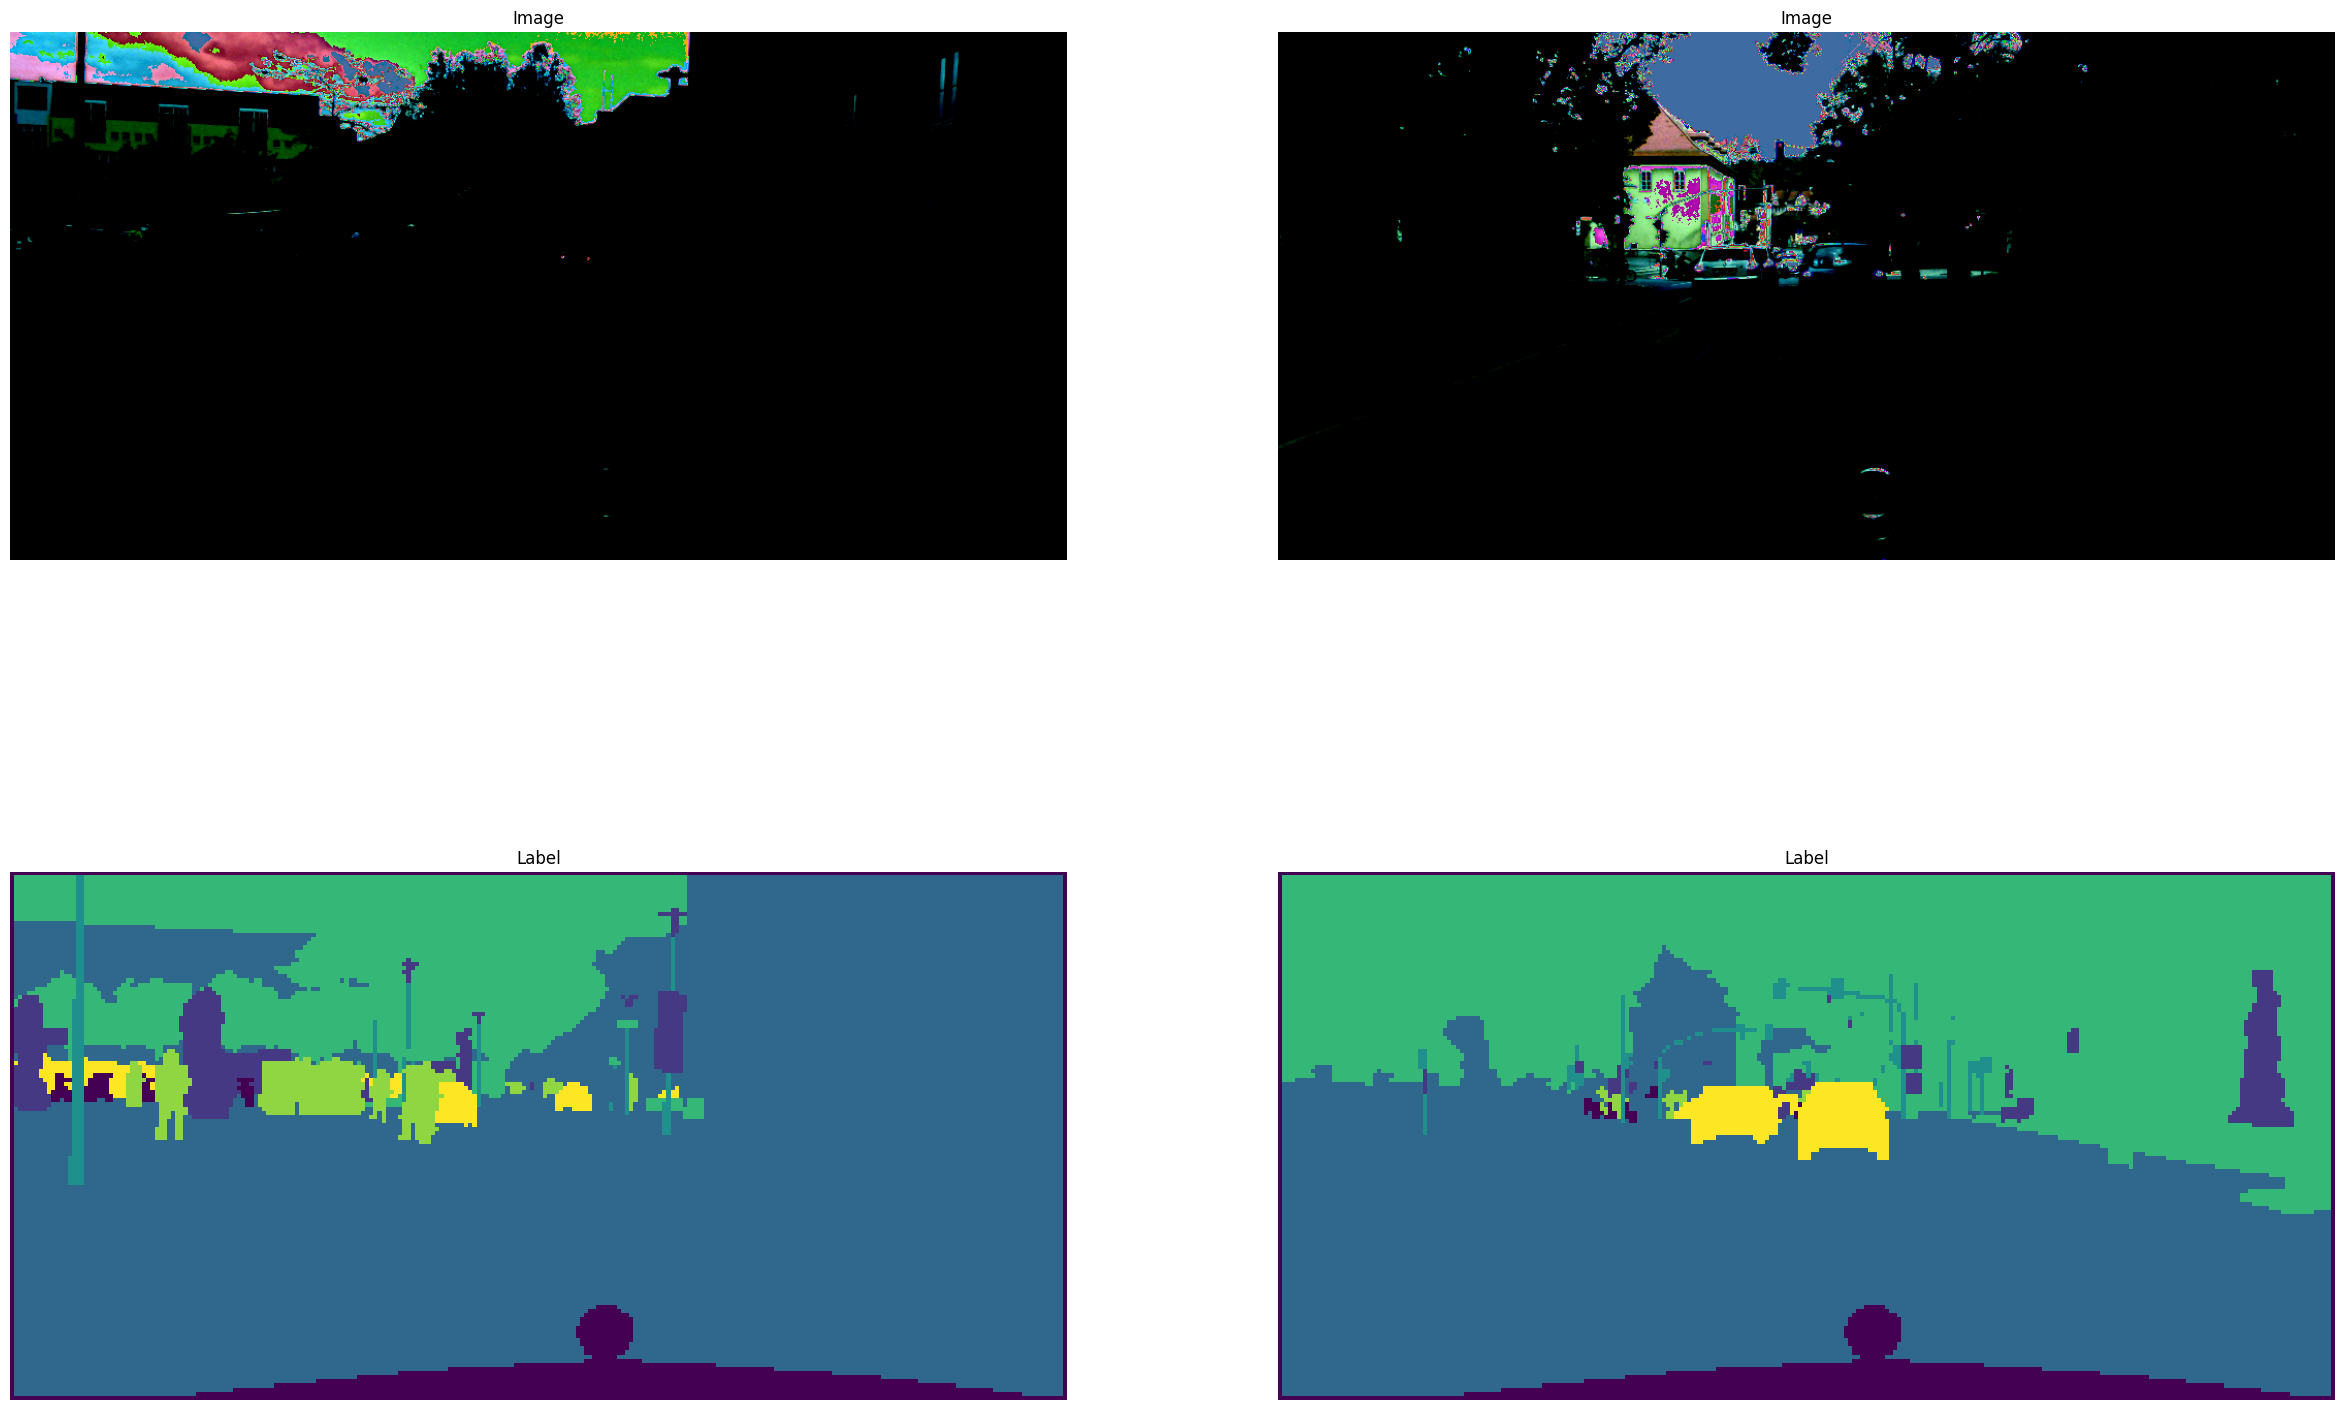

In [ ]:
for x, y in train_dataset.take(1):
    print(x.shape, x.dtype)
    print(y.shape, y.dtype)
    x = tf.transpose(x, perm=[0,2,3,1])

    plot_images_and_labels(x.numpy(),y.numpy())

# Segformer : Custom Training Loop

## Restaure model from stored model.keras file and checkpoint manager

In [66]:
model_restaure_path = "best_model.keras"

# Define model and optimizer
model = tf.keras.models.load_model(model_restaure_path)

/usr/local/lib/python3.10/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


In [67]:
pwd

'/content/drive/MyDrive/master_folder/semantic-segmentation/experiments'

In [68]:
# Reinitialize the optimizer and metrics
optimizer = tf.keras.optimizers.Adam()

checkpoint_restaure_path = "dir_checkpoint_"

# Load the model and optimizer state from the last checkpoint
checkpoint = tf.train.Checkpoint(optimizer=optimizer, model=model)

In [69]:
checkpoint_manager = tf.train.CheckpointManager(checkpoint, checkpoint_restaure_path, max_to_keep=3)

In [70]:
# Restore the latest checkpoint
if checkpoint_manager.latest_checkpoint:
    checkpoint.restore(checkpoint_manager.latest_checkpoint)
    print(f"Restored from {checkpoint_manager.latest_checkpoint}")
else:
    print("Initializing from scratch.")

Restored from dir_checkpoint_/ckpt-20


In [71]:
checkpoint = tf.train.Checkpoint(optimizer=optimizer, model=model)

## Mlflow start

In [73]:
# Start MLflow run and enable autologging
# !pip install mlflow
# import mlflow
mlflow.start_run()
mlflow.tensorflow.autolog()

## Class for maintaining the history of metrics, and optimization of traininng data

In [74]:
class CustomHistory(Callback):
    def on_train_begin(self, logs=None):
        self.history = {
            'loss': [],
            'accuracy': [],
            'val_loss': [],
            'val_accuracy': [],
            'dice_coefficient': [],
            'val_dice_coefficient': [],
            'iou': [],
            'val_iou': []
        }

    def on_epoch_end(self, epoch, logs=None):
        for key, value in logs.items():
            self.history[key].append(value)

## Custom-defined metrics of dice_coefficient and IoU

In [75]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = tf.keras.backend.flatten(tf.cast(y_pred, tf.float32))  # Ensure y_pred is float32
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def iou(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = tf.keras.backend.flatten(tf.cast(y_pred, tf.float32))  # Ensure y_pred is float32
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    sum_ = tf.keras.backend.sum(y_true_f + y_pred_f)
    iou = (intersection + smooth) / (sum_ - intersection + smooth)
    return iou

## Plotting Function for During and After training

In [88]:
def plot_predictions(images, masks, predictions, epoch):
    # Convert predictions to class labels
    predictions = tf.transpose(predictions, perm=[0, 2, 3, 1])

    predictions = tf.argmax(predictions, axis=-1)

    num_images = len(images)

    fig, axes = plt.subplots(3, 3, figsize=(15, num_images * 5))

    if num_images == 1:
        axes = [axes]

    for i, (image, mask, prediction) in enumerate(zip(images, masks, predictions)):
        if i > 2:
            break

        # Transpose image to (height, width, channels) if necessary
        image = tf.transpose(image, perm=[1, 2, 0]) if image.shape[0] == 3 else image
        mask = tf.transpose(mask, perm=[1, 2, 0]) if mask.shape[0] == 1 else mask
        mask = tf.squeeze(mask, axis=-1)  if mask.shape[-1] == 1 else mask

        prediction = tf.squeeze(prediction, axis=-1) if prediction.shape[-1] == 1 else prediction # Remove the last dimension if it is 1
        axes[i][0].imshow(image*255)
        axes[i][0].set_title(f'Epoch {epoch} - Input Image')
        axes[i][0].axis('off')

        axes[i][1].imshow(mask)
        axes[i][1].set_title('True Mask')
        axes[i][1].axis('off')

        axes[i][2].imshow(prediction)
        axes[i][2].set_title('Predicted Mask')
        axes[i][2].axis('off')

    plt.tight_layout()
    plt.savefig(f'static/predictions_epoch_{epoch}.png')
    plt.show()


In [89]:
# Instantiate the custom history callback and initialize history
custom_history = CustomHistory()
custom_history.on_train_begin()

## Tensorboard preparation

In [90]:
# Define the log directory for TensorBoard
log_dir = "tbrd_logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_writer = tf.summary.create_file_writer(log_dir)
print(f"TensorBoard log directory: {log_dir}")

TensorBoard log directory: tbrd_logs/fit/20240610-032858


## Segformer loss_fn, train_loss, train_accuracy, val_loss, val_accuracy

In [91]:
# Optimizer and loss function
# Create a base optimizer and wrap it with LossScaleOptimizer
loss_fn = SparseCategoricalCrossentropy(from_logits=True)

# Metrics
train_loss = Mean(name='train_loss')
train_accuracy = SparseCategoricalAccuracy(name='train_accuracy')
val_loss = Mean(name='val_loss')
val_accuracy = SparseCategoricalAccuracy(name='val_accuracy')

## Segformer: train_step and valid_step functions for custom training and validation steps

In [92]:
# @tf.function
@tf.function
def train_step(images, masks):
    with tf.GradientTape() as tape:
        # Get logits from the model
        logits = model(images, training=True).logits

        # Ensure logits have shape [batch_size, height, width, num_classes]
        logits = tf.transpose(logits, perm=[0, 2, 3, 1])

        # Ensure masks shape is correct
        masks = tf.squeeze(masks, axis=-1)

        # Compute loss using logits directly
        loss = loss_fn(masks, logits)

    # Compute gradients and apply them
    # scaled_loss = optimizer.get_scaled_loss(loss)
    gradients = tape.gradient(loss, model.trainable_variables)

    # scaled_gradients = optimizer.get_unscaled_gradients(gradients)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    # Update metrics with predictions (using argmax to get predicted classes)
    train_loss(loss)
    train_accuracy.update_state(masks, logits)
    return loss

@tf.function
def val_step(images, masks):
    # Get logits from the model
    # with tf.device('/CPU:0'):  # Ensure validation is done on CPU
    logits = model(images, training=False).logits

    # Ensure logits have shape [batch_size, height, width, num_classes]
    logits = tf.transpose(logits, perm=[0, 2, 3, 1])

    # Remove the last dimension of masks if it exists
    masks = tf.squeeze(masks, axis=-1)

    # Compute loss
    loss = loss_fn(masks, logits)

    # Update metrics with predictions (using argmax to get predicted classes)
    val_loss(loss)
    val_accuracy.update_state(masks, logits)
    return loss

### Segformer training loop

In [93]:
model_dir = "dir_models_/"

In [105]:
# Custom training loop
epochs = 120
best_val_loss = float('inf')
patience = 0
stop_callback = 0

for epoch in range(51,epochs):

    # Reset metrics at the start of each epoch
    train_loss.reset_states()
    train_accuracy.reset_states()
    val_loss.reset_states()
    val_accuracy.reset_states()

    # Training loop
    for images, masks in tqdm(train_dataset):
        train_step(images, masks)

    # Validation loop
    for val_images, val_masks in valid_dataset:
        val_step(val_images, val_masks)

    # Calculate custom metrics
    with tensorboard_writer.as_default():
        tf.summary.scalar('train_loss', train_loss.result(), step=epoch)
        tf.summary.scalar('train_accuracy', train_accuracy.result(), step=epoch)
        tf.summary.scalar('test_loss', val_loss.result(), step=epoch)
        tf.summary.scalar('test_accuracy', val_accuracy.result(), step=epoch)


    logits = model(val_images).logits
    logits = tf.transpose(logits, perm=[0, 2, 3, 1])
    dice_coef = dice_coefficient(val_masks, tf.argmax(logits, axis=-1, output_type=tf.int32)).numpy()
    val_dice_coef = dice_coefficient(val_masks, tf.argmax(logits, axis=-1, output_type=tf.int32)).numpy()
    iou_metric = iou(val_masks, tf.argmax(logits, axis=-1, output_type=tf.int32)).numpy()
    val_iou_metric = iou(val_masks, tf.argmax(logits, axis=-1, output_type=tf.int32)).numpy()


    # Log metrics to the custom history
    custom_history.on_epoch_end(epoch, logs={
        'loss': train_loss.result().numpy(),
        'accuracy': train_accuracy.result().numpy(),
        'val_loss': val_loss.result().numpy(),
        'val_accuracy': val_accuracy.result().numpy(),
        'dice_coefficient': dice_coef,
        'val_dice_coefficient': val_dice_coef,
        'iou': iou_metric,
        'val_iou': val_iou_metric
    })

    # Print current epoch metrics
    print(f'Epoch {epoch + 1}, '
          f'Loss: {train_loss.result()}, '
          f'Accuracy: {train_accuracy.result() * 100}, '
          f'Val Loss: {val_loss.result()}, '
          f'Val Accuracy: {val_accuracy.result() * 100}, '
          f'Dice Coefficient: {dice_coef}, '
          f'Val Dice Coefficient: {val_dice_coef}, '
          f'IoU: {iou_metric}, '
          f'Val IoU: {val_iou_metric}')

    # Log metrics to MLflow
    mlflow.log_metric('train_loss', train_loss.result().numpy(), step=epoch)
    mlflow.log_metric('train_accuracy', train_accuracy.result().numpy(), step=epoch)
    mlflow.log_metric('val_loss', val_loss.result().numpy(), step=epoch)
    mlflow.log_metric('val_accuracy', val_accuracy.result().numpy(), step=epoch)
    mlflow.log_metric('dice_coefficient', dice_coef, step=epoch)
    mlflow.log_metric('val_dice_coefficient', val_dice_coef, step=epoch)
    mlflow.log_metric('iou', iou_metric, step=epoch)
    mlflow.log_metric('val_iou', val_iou_metric, step=epoch)

    # Early stopping
    if val_loss.result() < best_val_loss:
        patience = 0
        stop_callback = 0
        best_val_loss = val_loss.result()

        # checkpoint.save(f"{checkpoint_dir}ckpt")
        model.save(f"{model_dir}best_model_epoch.{epoch+1}.keras")
        checkpoint_manager.save()

        print(f'New best model saved with val loss: {best_val_loss}')
    else:
        patience += 1
        stop_callback += 1

    # Plot and save predictions
    for val_images, val_masks in valid_dataset.take(1):
        predictions = model.predict(val_images).logits
        # mlflow.log_artifact(f'static/predictions_epoch_{epoch}.png')
        if epoch % 5 == 0:
            plot_predictions(val_images.numpy(), val_masks, predictions, epoch)

    # CALLBACK: reduce learning rate on plateau
    if (patience > 10) and (val_loss.result() > best_val_loss):
        patience = 0
        new_lr = optimizer.learning_rate.numpy() * 0.5
        if new_lr >= 1e-5:
            optimizer.learning_rate.assign(new_lr)
            print(f'Reduced learning rate to {new_lr}')

    # CALLBACK: trigger early stopping
    if stop_callback > 22:
        print(f"Early Stoppping callback triggered!")
        break
    gc.collect()

# Save the final model
final_model_path = f"final_model.keras"
model.save(final_model_path)
mlflow.log_artifact(final_model_path)

# End MLflow run
mlflow.end_run()

Output hidden; open in https://colab.research.google.com to view.

# Segformer Results

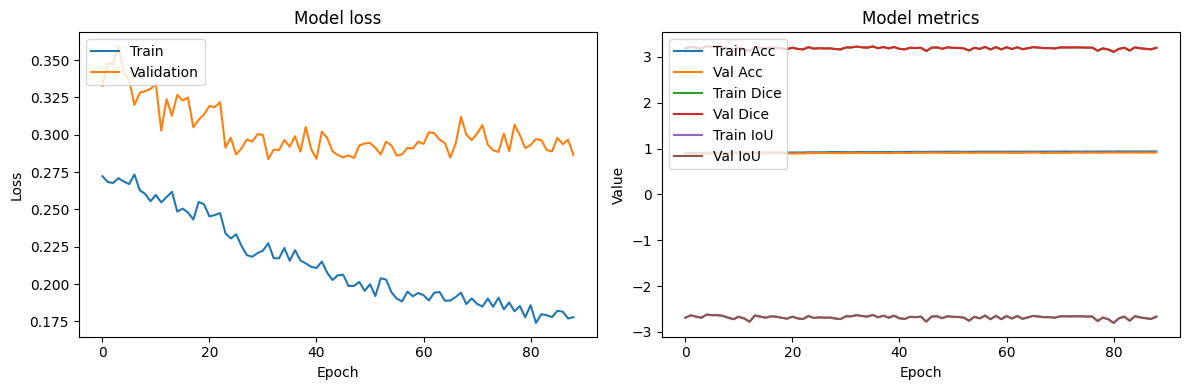

In [126]:
def plot_history(history):

    # Plot training & validation loss values
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'])
    plt.plot(history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'])
    plt.plot(history['val_accuracy'])
    plt.plot(history['dice_coefficient'])
    plt.plot(history['val_dice_coefficient'])
    plt.plot(history['iou'])
    plt.plot(history['val_iou'])
    plt.title('Model metrics')
    plt.ylabel('Value')
    plt.xlabel('Epoch')
    plt.legend(['Train Acc', 'Val Acc', 'Train Dice', 'Val Dice', 'Train IoU', 'Val IoU'], loc='upper left')

    plt.tight_layout()
    plt.show()

plot_history(custom_history.history)
